In [1]:
import tensorflow as tf
import gc

tf.keras.backend.clear_session()
gc.collect()

2026-06-05 17:28:21.527180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780680501.707029      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780680501.766700      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780680502.196565      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780680502.196628      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780680502.196635      58 computation_placer.cc:177] computation placer alr

0

In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/maheshdattatreya
/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage
/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage/archive (3)
/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage/archive (3)/archive (3)
/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage/archive (3)/archive (3)/PlantVillage
/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage/archive (3)/archive (3)/PlantVillage/PlantVillage
/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage/archive (3)/archive (3)/PlantVillage/PlantVillage/Pepper__bell___Bacterial_spot
/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage/archive (3)/archive (3)/PlantVillage/PlantVillage/Potato___healthy
/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage/archive (3)/archive (3)/PlantVillage/PlantVillage/Tomato_Leaf_Mold
/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage/archive (3)/archive

In [3]:
import os

dataset_path = "/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage/archive (3)/archive (3)/PlantVillage"

print(os.listdir(dataset_path))

['PlantVillage', 'Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']


In [4]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage/archive (3)/archive (3)/PlantVillage",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=8
)

Found 41276 files belonging to 16 classes.
Using 33021 files for training.


I0000 00:00:1780680559.573524      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780680559.579427      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


**Cell 1 Imports**

In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

from tensorflow.keras import layers

**Cell 2: Dataset Path**

In [6]:
dataset_path = "/kaggle/input/datasets/maheshdattatreya/cifar-and-plantvillage/archive (3)/archive (3)/PlantVillage"

**Cell 3: Load Dataset**

In [7]:
IMG_SIZE = (224,224)
BATCH_SIZE = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

Found 41276 files belonging to 16 classes.
Using 33021 files for training.
Found 41276 files belonging to 16 classes.
Using 8255 files for validation.


**Cell 4: Optimize Dataset**

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

**Cell 5: Carbon Calculation Functions**
Assumptions:

Kaggle T4 ≈ 70W average
Grid emission factor = 0.475 kg CO₂/kWh

In [12]:
GPU_POWER = 70

CARBON_FACTOR = 0.475

def energy_wh(seconds):
    return GPU_POWER * (seconds/3600)

def carbon_kg(energy_wh):
    return (energy_wh/1000) * CARBON_FACTOR

**Cell 6: Experimental Function**

In [13]:
results = []

def evaluate_model(model, name):

    start = time.time()

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=3,
        verbose=1
    )

    training_time = time.time() - start

    energy_train = energy_wh(training_time)

    carbon_train = carbon_kg(energy_train)

    for images, labels in val_ds.take(1):
        sample = images[:1]

    start = time.time()

    for _ in range(100):
        model.predict(sample, verbose=0)

    inference_time = (time.time() - start)/100

    energy_inf = energy_wh(inference_time)

    carbon_inf = carbon_kg(energy_inf)

    break_even = carbon_train/carbon_inf

    results.append([
        name,
        training_time,
        energy_train,
        carbon_train,
        inference_time,
        energy_inf,
        carbon_inf,
        break_even
    ])

**Cell 7: MobileNetV2**

In [14]:
mobilenet_base = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

mobilenet_base.trainable = False

mobilenet = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),

    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    mobilenet_base,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(16, activation='softmax')
])

mobilenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        20,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,278,480 (8.69 MB)

 Trainable params: 20,496 (80.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Cell 8: Train MobileNetV2**

In [15]:
evaluate_model(
    mobilenet,
    "MobileNetV2"
)

Epoch 1/3


I0000 00:00:1780680618.348374     139 service.cc:152] XLA service 0x7d5b34013300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780680618.348417     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780680618.348423     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780680619.387246     139 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-05 17:30:27.458827: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:30:27.595237: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1780680629.578384     139 device_co

4127/4128 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4681 - loss: 1.3392

2026-06-05 17:31:16.877008: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:31:17.013259: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


4128/4128 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4681 - loss: 1.3392

2026-06-05 17:31:40.814036: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:31:40.950220: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


4128/4128 ━━━━━━━━━━━━━━━━━━━━ 89s 18ms/step - accuracy: 0.4669 - loss: 1.2237 - val_accuracy: 0.4661 - val_loss: 1.0559
Epoch 2/3
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 50s 12ms/step - accuracy: 0.4748 - loss: 1.1194 - val_accuracy: 0.4612 - val_loss: 1.1078
Epoch 3/3
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 51s 12ms/step - accuracy: 0.4789 - loss: 1.1031 - val_accuracy: 0.4353 - val_loss: 1.0799


2026-06-05 17:33:33.076616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:33:33.221171: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:33:33.355254: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


**Cell 9: EfficientNetB0**

In [16]:
base = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base.trainable = False

efficientnet = tf.keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(len(class_names), activation='softmax')
])

efficientnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Cell 10: Train EfficientNetB0**

In [17]:
evaluate_model(
    efficientnet,
    "EfficientNetB0"
)

Epoch 1/3


2026-06-05 17:34:54.355480: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:34:54.491499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:34:54.795828: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:34:54.936227: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:34:55.704409: E external/local_xla/xla/stream_

4124/4128 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4843 - loss: 1.2448

2026-06-05 17:35:56.518148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:35:56.653595: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:35:56.964647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:35:57.104945: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:35:57.863181: E external/local_xla/xla/stream_

4128/4128 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4843 - loss: 1.2446

2026-06-05 17:36:24.214773: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:36:24.350548: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:36:24.656357: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:36:24.796550: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:36:25.561538: E external/local_xla/xla/stream_

4128/4128 ━━━━━━━━━━━━━━━━━━━━ 108s 21ms/step - accuracy: 0.4821 - loss: 1.0939 - val_accuracy: 0.4753 - val_loss: 0.9941
Epoch 2/3
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 62s 15ms/step - accuracy: 0.4857 - loss: 0.9718 - val_accuracy: 0.4556 - val_loss: 0.9845
Epoch 3/3
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 62s 15ms/step - accuracy: 0.4889 - loss: 0.9452 - val_accuracy: 0.4488 - val_loss: 0.9905


2026-06-05 17:38:37.794860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:38:37.929976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:38:38.669700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 17:38:38.805000: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


**Cell 11: Results Table**

In [18]:
columns = [
    "Model",
    "Training_Time_sec",
    "Training_Energy_Wh",
    "Training_CO2_kg",
    "Inference_Time_sec",
    "Inference_Energy_Wh",
    "Inference_CO2_kg",
    "BreakEven_Inferences"
]

df = pd.DataFrame(
    results,
    columns=columns
)

df

,Model,Training_Time_sec,Training_Energy_Wh,Training_CO2_kg,Inference_Time_sec,Inference_Energy_Wh,Inference_CO2_kg,BreakEven_Inferences
0,MobileNetV2,190.413469,3.702484,0.001759,0.185650,0.003610,0.000002,1025.658786
1,EfficientNetB0,231.355511,4.498579,0.002137,0.177144,0.003444,0.000002,1306.030430


**Cell 12: Training vs Inference Carbon**

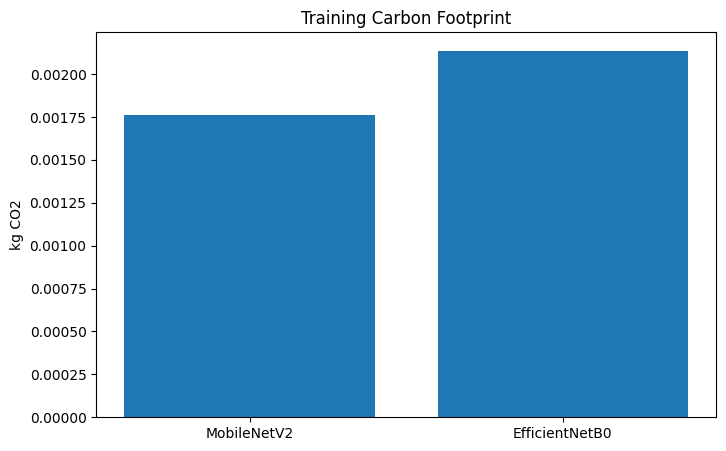

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Model"],
    df["Training_CO2_kg"]
)

plt.ylabel("kg CO2")

plt.title(
    "Training Carbon Footprint"
)

plt.show()

**Cell 13: Break-Even Analysis**

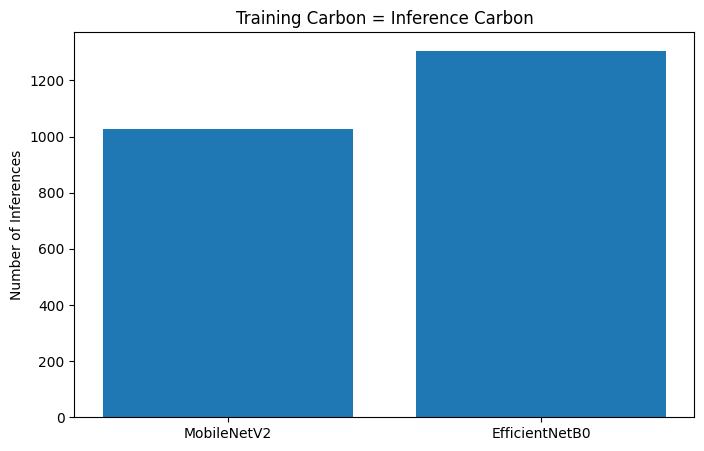

In [20]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Model"],
    df["BreakEven_Inferences"]
)

plt.ylabel(
    "Number of Inferences"
)

plt.title(
    "Training Carbon = Inference Carbon"
)

plt.show()

**Cell 14: Lifecycle Analysis**

In [21]:
deployment_sizes = [
    1000,
    10000,
    100000,
    1000000
]

for _, row in df.iterrows():

    print("\n", row["Model"])

    for n in deployment_sizes:

        total_carbon = (
            row["Training_CO2_kg"] +
            n * row["Inference_CO2_kg"]
        )

        print(
            f"{n:,} inferences -> "
            f"{total_carbon:.6f} kg CO2"
        )


 MobileNetV2
1,000 inferences -> 0.003473 kg CO2
10,000 inferences -> 0.018906 kg CO2
100,000 inferences -> 0.173227 kg CO2
1,000,000 inferences -> 1.716442 kg CO2

 EfficientNetB0
1,000 inferences -> 0.003773 kg CO2
10,000 inferences -> 0.018498 kg CO2
100,000 inferences -> 0.165749 kg CO2
1,000,000 inferences -> 1.638259 kg CO2
